In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.ticker as mticker
import pickle
import os
import sys

PROJECT_ROOT = os.path.abspath("..")
sys.path.insert(0, PROJECT_ROOT)

from src.local_config import *
from src.trading_signal import *
from src.backtest import *
from src.rolling_backtest import *

In [2]:
# Load Kalman details and combine IS + OOS into one continuous dict
with open(PROJECT_ROOT / "data/dictionaries/dynamic_details_is.pkl", "rb") as f:
    dynamic_details_is = pickle.load(f)
with open(PROJECT_ROOT / "data/dictionaries/dynamic_details_oos.pkl", "rb") as f:
    dynamic_details_oos = pickle.load(f)

dynamic_details_full = {}
for key in dynamic_details_oos:
    is_df  = dynamic_details_is.get(key, pd.DataFrame())
    oos_df = dynamic_details_oos[key]
    dynamic_details_full[key] = pd.concat([is_df, oos_df]).sort_index()

In [3]:
# Filter to portfolio pairs
portfolio       = pd.read_csv(PROJECT_ROOT / "data/portfolio")
weights         = portfolio.set_index("pair")["weight"].to_dict()
portfolio_pairs = set(portfolio["pair"])

dynamic_details_full = {k: v for k, v in dynamic_details_full.items() if k[0] in portfolio_pairs}

# Combined risk-free rate
rf_is   = pd.read_csv(PROJECT_ROOT / "data/rf_is",  index_col=0, parse_dates=True)
rf_oos  = pd.read_csv(PROJECT_ROOT / "data/rf_oos", index_col=0, parse_dates=True)
rf_full = pd.concat([rf_is, rf_oos]).sort_index()

print("Pairs:", sorted(set(k[0] for k in dynamic_details_full)))
ref = dynamic_details_full[next(iter(dynamic_details_full))]
print("Date range:", ref.index[0].date(), "→", ref.index[-1].date())

Pairs: ['1258 HK Equity vs 3899 HK Equity', '1347 HK Equity vs 268 HK Equity', '3993 HK Equity vs 2689 HK Equity', '857 HK Equity vs 2386 HK Equity']
Date range: 2015-01-02 → 2025-12-31


In [4]:
entry_values = [1.0, 1.5, 2.0]
exit_values  = [0.0, 0.5, 1.0]

rolling_results = {}

for e in entry_values:
    for x in exit_values:
        key = f"entry_{e}_exit_{x}"
        rolling_results[key] = walk_forward_backtest(
            dynamic_details = dynamic_details_full,
            weights         = weights,
            entry_z         = e,
            exit_z          = x,
            obs_cov         = 1.0,
            is_window       = 262,
            oos_step        = 63,
        )

print("Strategies computed:", list(rolling_results.keys()))

Strategies computed: ['entry_1.0_exit_0.0', 'entry_1.0_exit_0.5', 'entry_1.0_exit_1.0', 'entry_1.5_exit_0.0', 'entry_1.5_exit_0.5', 'entry_1.5_exit_1.0', 'entry_2.0_exit_0.0', 'entry_2.0_exit_0.5', 'entry_2.0_exit_1.0']


In [5]:
# Performance metrics for all strategies
metrics_rows = []
for key, ret in rolling_results.items():
    rf_aligned = rf_full.reindex(ret.index).ffill()
    m = performance_metrics(ret, rf=rf_aligned)
    m["strategy"] = key
    metrics_rows.append(m)

rolling_metrics_df = pd.DataFrame(metrics_rows).set_index("strategy")
rolling_metrics_df

,avg_return (%),avg_excess_return (%),annualised_sharpe,total_pnl,hit_rate (%),max_drawdown (%),num_obs
strategy,,,,,,,
entry_1.0_exit_0.0,0.2331,0.2311,1.7580,15591.33,53.93,-30.08,2394.0
entry_1.0_exit_0.5,0.1848,0.1855,1.8161,5992.31,55.75,-25.32,2394.0
entry_1.0_exit_1.0,0.1650,0.1649,1.8037,3947.79,57.36,-22.65,2394.0
entry_1.5_exit_0.0,0.1980,0.1942,1.4693,6631.80,53.30,-26.09,2394.0
entry_1.5_exit_0.5,0.1645,0.1643,1.7693,3856.18,55.64,-23.12,2394.0
entry_1.5_exit_1.0,0.1321,0.1318,1.6211,1838.03,56.22,-20.82,2394.0
entry_2.0_exit_0.0,0.2209,0.2170,1.6290,11604.68,53.93,-30.87,2394.0
entry_2.0_exit_0.5,0.1413,0.1409,1.7209,2309.96,55.76,-22.36,2394.0
entry_2.0_exit_1.0,0.0974,0.0955,1.3671,790.51,55.28,-24.26,2394.0


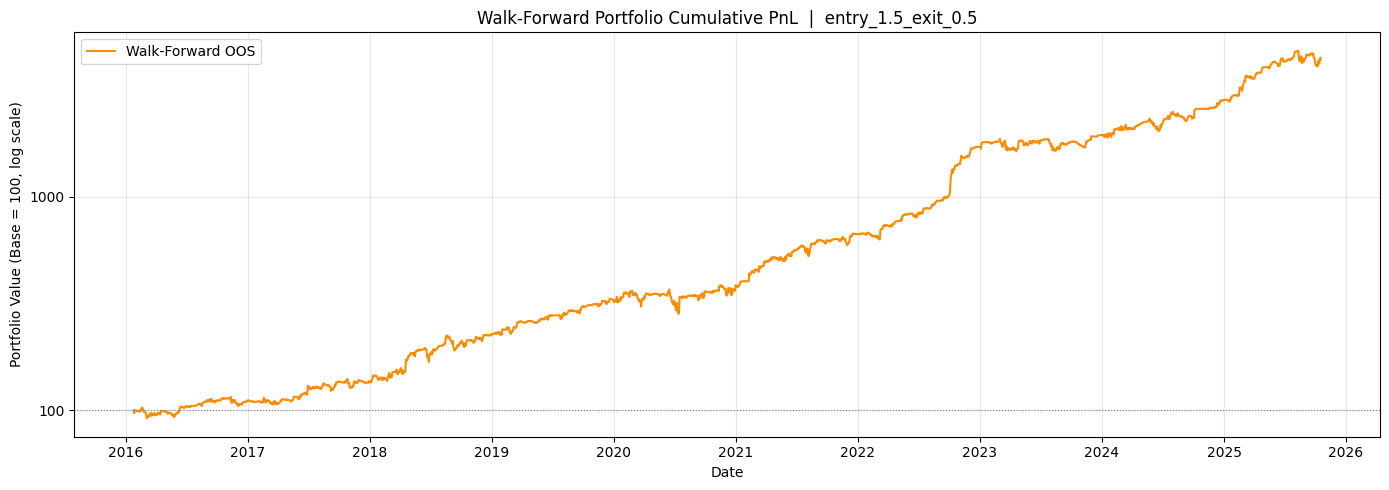

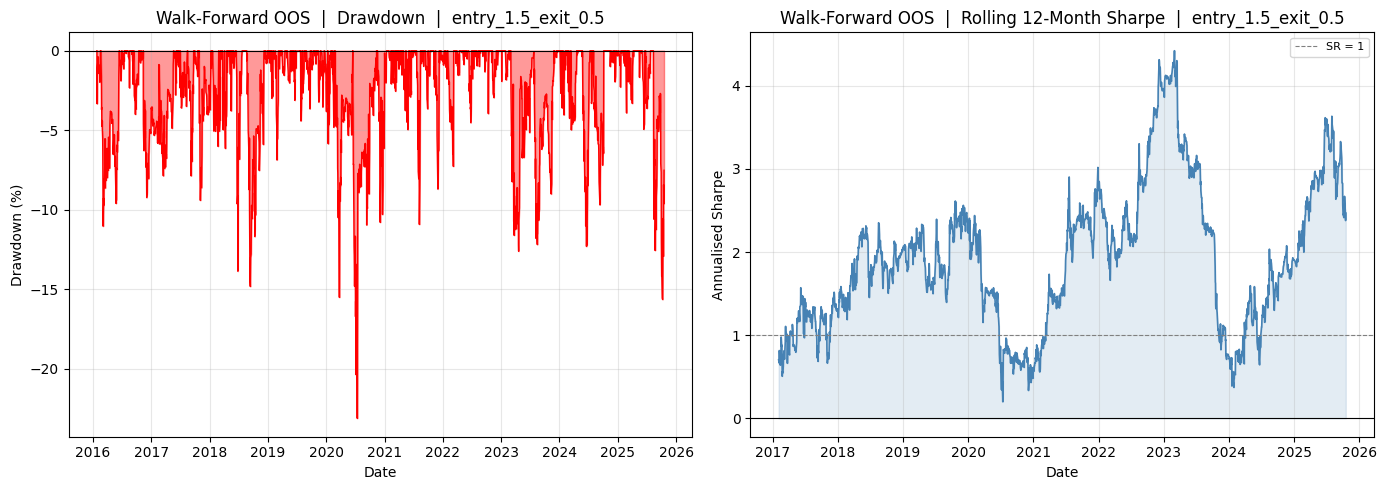

In [6]:
save_dir = PROJECT_ROOT / "outputs/rolling_outputs"
os.makedirs(save_dir, exist_ok=True)

rolling_ret = rolling_results["entry_1.5_exit_0.5"]
rolling_cum = 100 * (1 + rolling_ret.fillna(0)).cumprod()
roll_sr     = rolling_sharpe(rolling_ret, window=252)
drawdown    = (rolling_cum - rolling_cum.cummax()) / rolling_cum.cummax() * 100

# Single Plot
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(rolling_cum.index, rolling_cum, color="darkorange", lw=1.5, label="Walk-Forward OOS")
ax.axhline(100, color="grey", linestyle=":", lw=0.8)
ax.set_yscale("log")
ax.yaxis.set_major_locator(mticker.LogLocator(base=10, numticks=10))
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x)}"))
ax.yaxis.set_minor_locator(mticker.NullLocator())
ax.set_title("Walk-Forward Portfolio Cumulative PnL  |  entry_1.5_exit_0.5")
ax.set_ylabel("Portfolio Value (Base = 100, log scale)")
ax.set_xlabel("Date")
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(save_dir / "WalkForward_entry_2.0_exit_0.0_cumulative_pnl.png", dpi=300, bbox_inches="tight")
plt.show()

# Side-by-side Plot
strategy_name = "entry_1.5_exit_0.5"
rolling_ret   = rolling_results[strategy_name]
rolling_cum   = 100 * (1 + rolling_ret.fillna(0)).cumprod()
roll_sr       = rolling_sharpe(rolling_ret, window=252)
drawdown      = (rolling_cum - rolling_cum.cummax()) / rolling_cum.cummax() * 100

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=False)

axes[0].fill_between(drawdown.index, drawdown, 0, alpha=0.4, color="red")
axes[0].plot(drawdown.index, drawdown, color="red", lw=1.0)
axes[0].axhline(0, color="black", lw=0.8)
axes[0].set_title(f"Walk-Forward OOS  |  Drawdown  |  {strategy_name}")
axes[0].set_ylabel("Drawdown (%)")
axes[0].set_xlabel("Date")
axes[0].xaxis.set_major_locator(mdates.YearLocator())
axes[0].xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
axes[0].grid(True, alpha=0.3)

axes[1].plot(roll_sr.index, roll_sr, color="steelblue", lw=1.2)
axes[1].axhline(0, color="black", lw=0.8)
axes[1].axhline(1, color="grey", linestyle="--", lw=0.8, label="SR = 1")
axes[1].fill_between(roll_sr.index, 0, roll_sr, where=roll_sr >= 0, alpha=0.15, color="steelblue")
axes[1].fill_between(roll_sr.index, 0, roll_sr, where=roll_sr <  0, alpha=0.15, color="red")
axes[1].set_title(f"Walk-Forward OOS  |  Rolling 12-Month Sharpe  |  {strategy_name}")
axes[1].set_ylabel("Annualised Sharpe")
axes[1].set_xlabel("Date")
axes[1].xaxis.set_major_locator(mdates.YearLocator())
axes[1].xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
axes[1].legend(fontsize=8)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(save_dir / f"WalkForward_{strategy_name}_drawdown_and_sharpe.png", dpi=300, bbox_inches="tight")
plt.show()

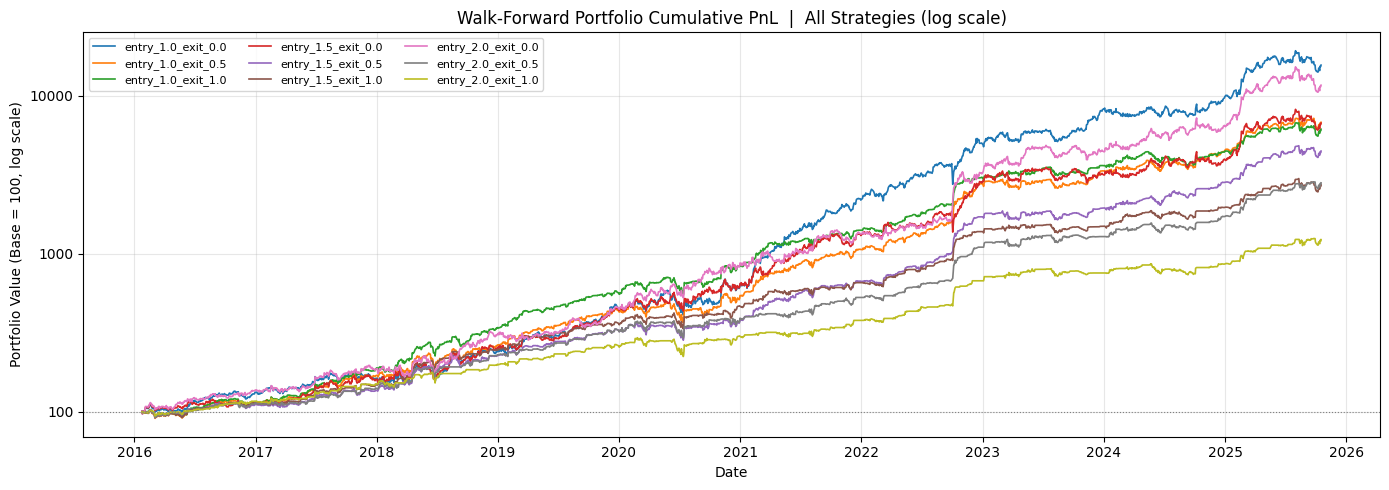

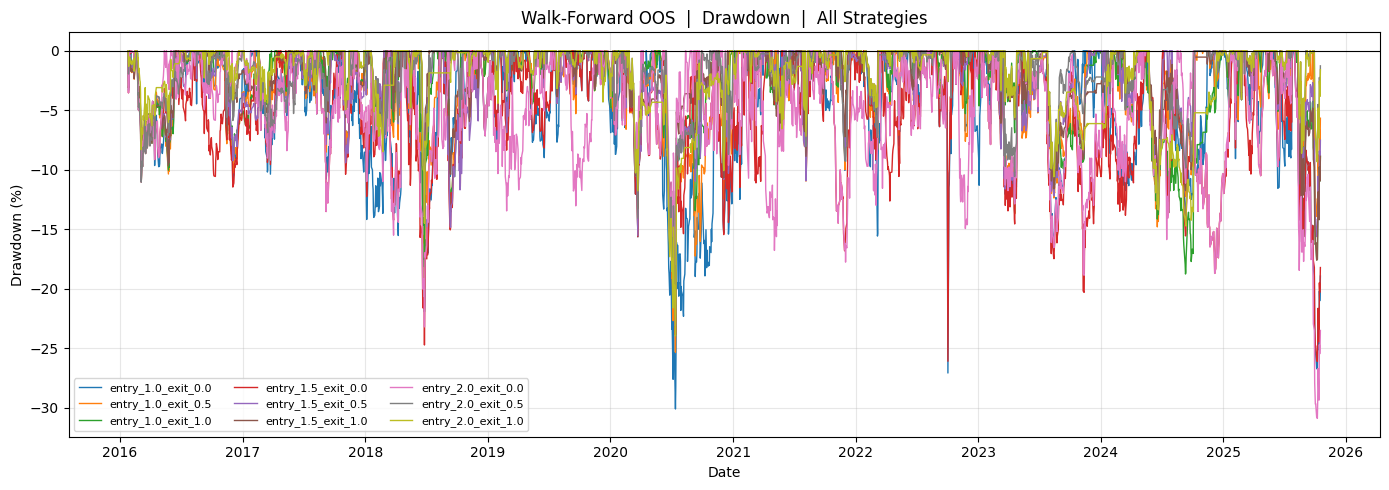

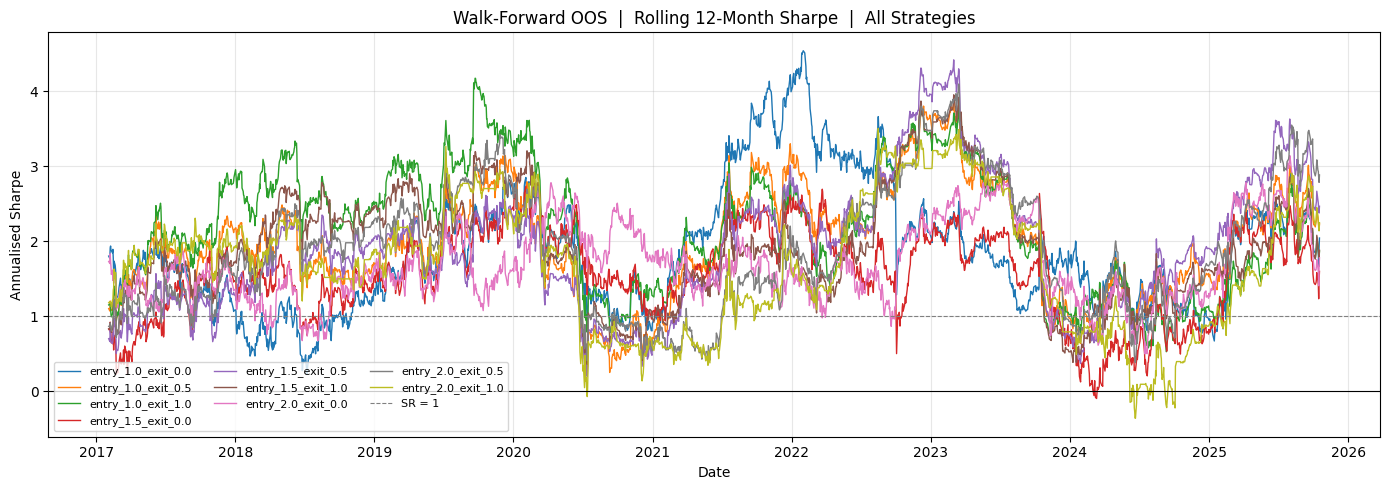

In [7]:
colors = plt.cm.tab10.colors

# Cum PnL
fig, ax = plt.subplots(figsize=(14, 5))
for i, (key, ret) in enumerate(rolling_results.items()):
    cum = 100 * (1 + ret.fillna(0)).cumprod()
    ax.plot(cum.index, cum, lw=1.2, color=colors[i], label=key)

ax.axhline(100, color="grey", linestyle=":", lw=0.8)
ax.set_yscale("log")
ax.yaxis.set_major_locator(mticker.LogLocator(base=10, numticks=10))
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x)}"))
ax.yaxis.set_minor_locator(mticker.NullLocator())
ax.set_title("Walk-Forward Portfolio Cumulative PnL  |  All Strategies (log scale)")
ax.set_ylabel("Portfolio Value (Base = 100, log scale)")
ax.set_xlabel("Date")
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
ax.legend(fontsize=8, ncol=3)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(save_dir / "WalkForward_All_Strategies_cumulative_pnl.png", dpi=300, bbox_inches="tight")
plt.show()

# Drawdown
fig, ax = plt.subplots(figsize=(14, 5))
for i, (key, ret) in enumerate(rolling_results.items()):
    cum      = 100 * (1 + ret.fillna(0)).cumprod()
    drawdown = (cum - cum.cummax()) / cum.cummax() * 100
    ax.plot(drawdown.index, drawdown, lw=1.0, color=colors[i], label=key)

ax.axhline(0, color="black", lw=0.8)
ax.set_title("Walk-Forward OOS  |  Drawdown  |  All Strategies")
ax.set_ylabel("Drawdown (%)")
ax.set_xlabel("Date")
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
ax.legend(fontsize=8, ncol=3)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(save_dir / "WalkForward_All_Strategies_drawdown.png", dpi=300, bbox_inches="tight")
plt.show()

# Sharpe
fig, ax = plt.subplots(figsize=(14, 5))
for i, (key, ret) in enumerate(rolling_results.items()):
    roll_sr = rolling_sharpe(ret, window=252)
    ax.plot(roll_sr.index, roll_sr, lw=1.0, color=colors[i], label=key)

ax.axhline(0, color="black", lw=0.8)
ax.axhline(1, color="grey", linestyle="--", lw=0.8, label="SR = 1")
ax.set_title("Walk-Forward OOS  |  Rolling 12-Month Sharpe  |  All Strategies")
ax.set_ylabel("Annualised Sharpe")
ax.set_xlabel("Date")
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
ax.legend(fontsize=8, ncol=3)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(save_dir / "WalkForward_All_Strategies_sharpe.png", dpi=300, bbox_inches="tight")
plt.show()

In [8]:
# Walk-forward backtest using the refined signal (dynamic z-score bands)
rolling_ret_refined = walk_forward_refined_backtest(
    dynamic_details = dynamic_details_full,
    weights         = weights,
    obs_cov         = 1.0,
    is_window       = 262,
    oos_step        = 63,
)

print(f"Refined walk-forward OOS observations : {len(rolling_ret_refined)}")
print(f"Date range : {rolling_ret_refined.index[0].date()} → {rolling_ret_refined.index[-1].date()}")

Refined walk-forward OOS observations : 2356
Date range : 2016-01-26 → 2025-10-17


# Performance metrics — Refined

In [9]:
rf_aligned          = rf_full.reindex(rolling_ret.index).ffill()
metrics             = performance_metrics(rolling_ret,         rf=rf_aligned)

rf_aligned_refined  = rf_full.reindex(rolling_ret_refined.index).ffill()
metrics_refined     = performance_metrics(rolling_ret_refined, rf=rf_aligned_refined)

pd.DataFrame(
    [metrics, metrics_refined],
    index=["Baseline Walk-Forward", "Refined Walk-Forward"]
)

rf_aligned_refined = rf_full.reindex(rolling_ret_refined.index).ffill()
metrics_refined = performance_metrics(rolling_ret_refined, rf=rf_aligned_refined)

pd.DataFrame(
    [metrics, metrics_refined],
    index=["Baseline Walk-Forward", "Refined Walk-Forward"]
)

,avg_return (%),avg_excess_return (%),annualised_sharpe,total_pnl,hit_rate (%),max_drawdown (%),num_obs
Baseline Walk-Forward,0.1645,0.1643,1.7693,3856.18,55.64,-23.12,2394.0
Refined Walk-Forward,0.1643,0.1637,1.5984,3414.91,54.57,-23.43,2356.0


In [10]:
# For all z-entry and z-exit values
refined_rolling_results = {}

for e in entry_values:
    for x in exit_values:
        key = f"entry_{e}_exit_{x}"
        refined_rolling_results[key] = walk_forward_refined_backtest(
            dynamic_details = dynamic_details_full,
            weights         = weights,
            obs_cov         = 1.0,
            is_window       = 262,
            oos_step        = 63,
            exit_z          = x,
        )

baseline_metrics_all = {}
refined_metrics_all  = {}

for key in rolling_results:
    rf_b = rf_full.reindex(rolling_results[key].index).ffill()
    rf_r = rf_full.reindex(refined_rolling_results[key].index).ffill()
    baseline_metrics_all[key] = performance_metrics(rolling_results[key],         rf=rf_b)
    refined_metrics_all[key]  = performance_metrics(refined_rolling_results[key], rf=rf_r)

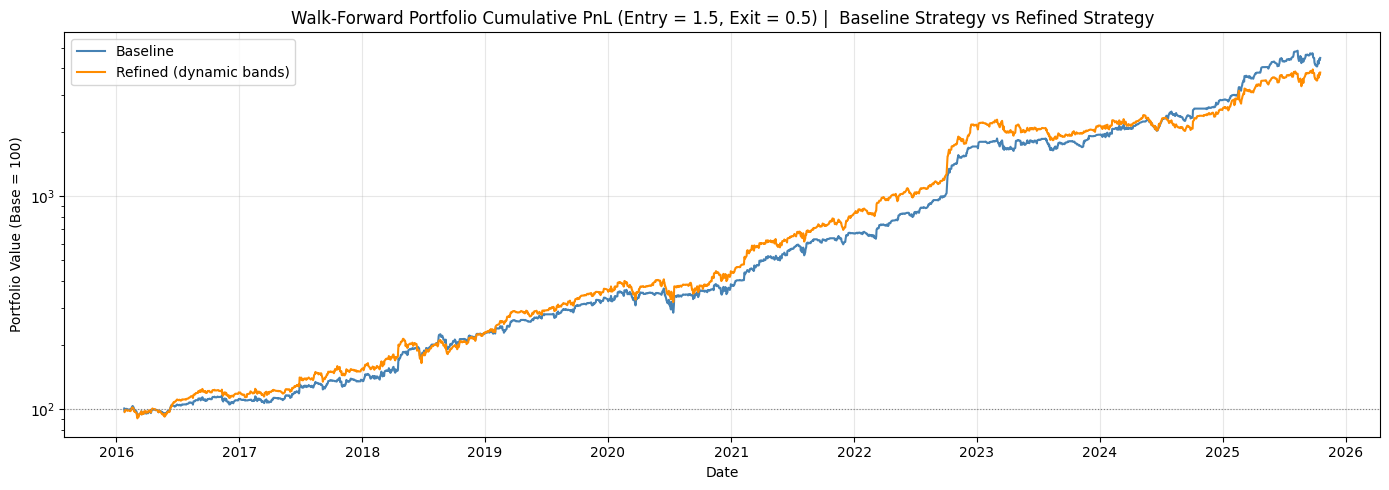

In [11]:
# Compare baseline vs refined walk-forward cumulative PnL
cum_baseline = 100 * (1 + rolling_ret.fillna(0)).cumprod()
cum_refined  = 100 * (1 + rolling_ret_refined.fillna(0)).cumprod()

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(cum_baseline.index, cum_baseline, color="steelblue",  lw=1.5, label="Baseline")
ax.plot(cum_refined.index,  cum_refined,  color="darkorange", lw=1.5, label="Refined (dynamic bands)")
ax.axhline(100, color="grey", linestyle=":", lw=0.8)

# Log-Scaled PnL 
ax.set_yscale("log")
ax.set_title("Walk-Forward Portfolio Cumulative PnL (Entry = 1.5, Exit = 0.5) |  Baseline Strategy vs Refined Strategy")
ax.set_ylabel("Portfolio Value (Base = 100)")
ax.set_xlabel("Date")
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [12]:
for key in rolling_results:
    cum_baseline = 100 * (1 + rolling_results[key].fillna(0)).cumprod()
    cum_refined  = 100 * (1 + refined_rolling_results[key].fillna(0)).cumprod()

    fig, ax = plt.subplots(figsize=(14, 5))
    ax.plot(cum_baseline.index, cum_baseline, color="steelblue",  lw=1.5, label="Baseline")
    ax.plot(cum_refined.index,  cum_refined,  color="darkorange", lw=1.5, label="Refined (dynamic bands)")
    ax.axhline(100, color="grey", linestyle=":", lw=0.8)
    ax.set_yscale("log")
    ax.set_title(f"Walk-Forward PnL  |  {key}  |  Baseline vs Refined (log scale)")
    ax.set_ylabel("Portfolio Value (Base = 100, log scale)")
    ax.set_xlabel("Date")
    ax.xaxis.set_major_locator(mdates.YearLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
    ax.legend()
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(save_dir / f"{key}_baseline_vs_refined.png", dpi=300, bbox_inches="tight")
    plt.close()

print(f"Saved {len(rolling_results)} plots to: {save_dir}")

Saved 9 plots to: /Users/ivanhung/Documents/GitHub/applied-project-06039211/outputs/rolling_outputs
